# Exploratory Data Analysis: Enron Spam Dataset

**Project:** Secure Local Mail System with ML-Based Spam Detection  
**Author:** Abdulla AlBassam  
**Module:** KV6013, Individual Computing Project  

A first pass over the Enron spam dataset before any model code gets written. The point is to understand the class balance, text length spread, vocabulary character, and any data-quality issues that the preprocessing pipeline needs to handle. Anything that surprises me here is an input to the choices in notebook 02.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from preprocessing import load_enron_data, clean_text

# 150 dpi gives charts that look decent in Jupyter and still print well
# without being too heavy to render.
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150

print('Libraries loaded.')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully.


## 1. Load the Dataset

In [2]:
df = load_enron_data('../data/raw/enron_spam_data.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Data types:\n{df.dtypes}')
print()
df.head(10)

Dataset shape: (33716, 5)
Columns: ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']
Data types:
Message ID     int64
Subject       object
Message       object
Spam/Ham      object
Date          object
dtype: object



,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
5,5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14
6,6,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14
7,7,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
8,8,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14
9,9,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14


## 2. Class distribution

If the classes are roughly balanced, accuracy is a sensible headline metric and there's no need for resampling tricks like SMOTE or undersampling. If they're not, I'd need to switch to F1 / ROC-AUC and possibly re-sample. Worth checking before anything else.

Class Distribution:
  spam: 17,171 (50.9%)
  ham: 16,545 (49.1%)


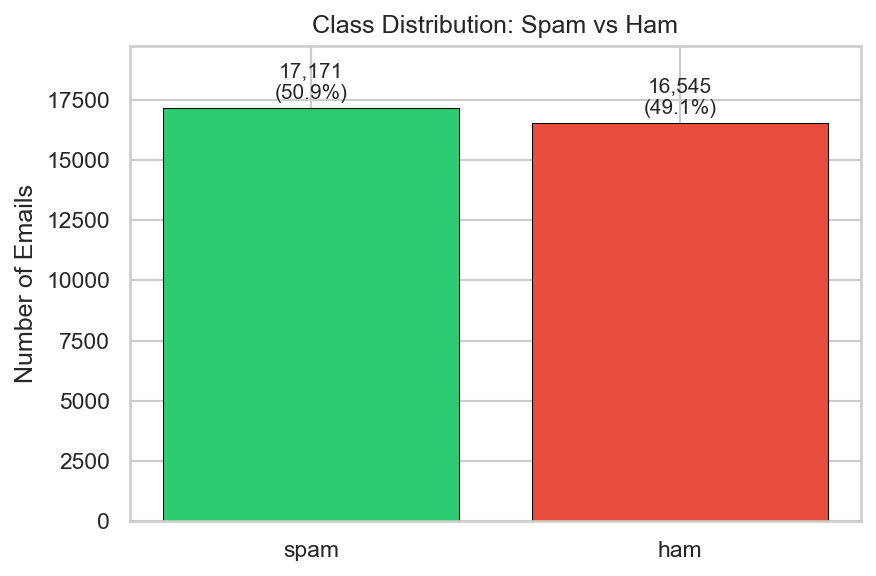

In [3]:
class_counts = df['Spam/Ham'].value_counts()
class_pcts = df['Spam/Ham'].value_counts(normalize=True) * 100

print('Class Distribution:')
for label in class_counts.index:
    print(f'  {label}: {class_counts[label]:,} ({class_pcts[label]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, count, pct in zip(bars, class_counts.values, class_pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Number of Emails')
ax.set_title('Class Distribution: Spam vs Ham')
ax.set_ylim(0, max(class_counts.values) * 1.15)
plt.tight_layout()
plt.show()

## 3. Missing data audit

Checking nulls and empty strings across every column, with the Message field as the main concern: an empty body still carries a label, and I want to know whether dropping those rows costs me a meaningful slice of either class.

In [ ]:
print('Null values per column:')
print(df.isnull().sum())
print()

# Check for empty strings in Message and Subject
empty_message = df['Message'].isna() | (df['Message'].astype(str).str.strip() == '')
empty_subject = df['Subject'].isna() | (df['Subject'].astype(str).str.strip() == '')

print(f'Rows with empty Message body: {empty_message.sum()}')
print(f'Rows with empty Subject line: {empty_subject.sum()}')
print(f'Rows with BOTH empty: {(empty_message & empty_subject).sum()}')
print()

# What class are the empty-message rows?
empty_msg_df = df[empty_message]
print('Class distribution of empty-message rows:')
print(empty_msg_df['Spam/Ham'].value_counts())
print()

# Show some examples of empty-message rows that have subjects
has_subject_no_message = empty_message & ~empty_subject
print(f'Rows with Subject but no Message: {has_subject_no_message.sum()}')
if has_subject_no_message.sum() > 0:
    print('\nExamples:')
    print(df[has_subject_no_message][['Subject', 'Spam/Ham']].head(10).to_string())

Null values per column:
Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64

Rows with empty Message body: 371
Rows with empty Subject line: 289
Rows with BOTH empty: 51

Class distribution of empty-message rows:
Spam/Ham
spam    319
ham      52
Name: count, dtype: int64

Rows with Subject but no Message: 320

Examples:
                                                                                                                                                                                                                                                                                                                                          Subject Spam/Ham
0                                                                                                                                                                                                                                                                                       

## 4. Text length analysis

The shape of the length distribution feeds two later choices: the TF-IDF max_features cap (notebook 02) and the DistilBERT max_length truncation (notebook 03). TF-IDF copes with variable-length documents fine via term-frequency normalisation, but anything in the long tail above ~50K characters is going to be truncated by DistilBERT at 256 tokens, so I want to see how much of the corpus that affects.

In [5]:
df['msg_length'] = df['Message'].astype(str).apply(len)
df['subj_length'] = df['Subject'].astype(str).apply(len)

# Summary statistics by class
print('Message length statistics by class:')
print(df.groupby('Spam/Ham')['msg_length'].describe().round(1))
print()
print('Subject length statistics by class:')
print(df.groupby('Spam/Ham')['subj_length'].describe().round(1))

Message length statistics by class:
            count    mean     std  min    25%    50%     75%       max
Spam/Ham                                                              
ham       16545.0  1676.3  5774.6  1.0  308.0  766.0  1665.0  228353.0
spam      17171.0  1271.9  1954.0  1.0  308.0  605.0  1333.0   28688.0

Subject length statistics by class:
            count  mean   std  min   25%   50%   75%     max
Spam/Ham                                                    
ham       16545.0  31.2  26.3  1.0  18.0  28.0  41.0  1355.0
spam      17171.0  37.9  53.6  1.0  22.0  34.0  47.0  3153.0


/var/folders/hc/4shpkczn2xj71yd6y83h_rdr0000gn/T/ipykernel_82794/3351003583.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='Spam/Ham', y='msg_length', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, ax=axes[1, 0])
/var/folders/hc/4shpkczn2xj71yd6y83h_rdr0000gn/T/ipykernel_82794/3351003583.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spam/Ham', y='subj_length', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, ax=axes[1, 1])


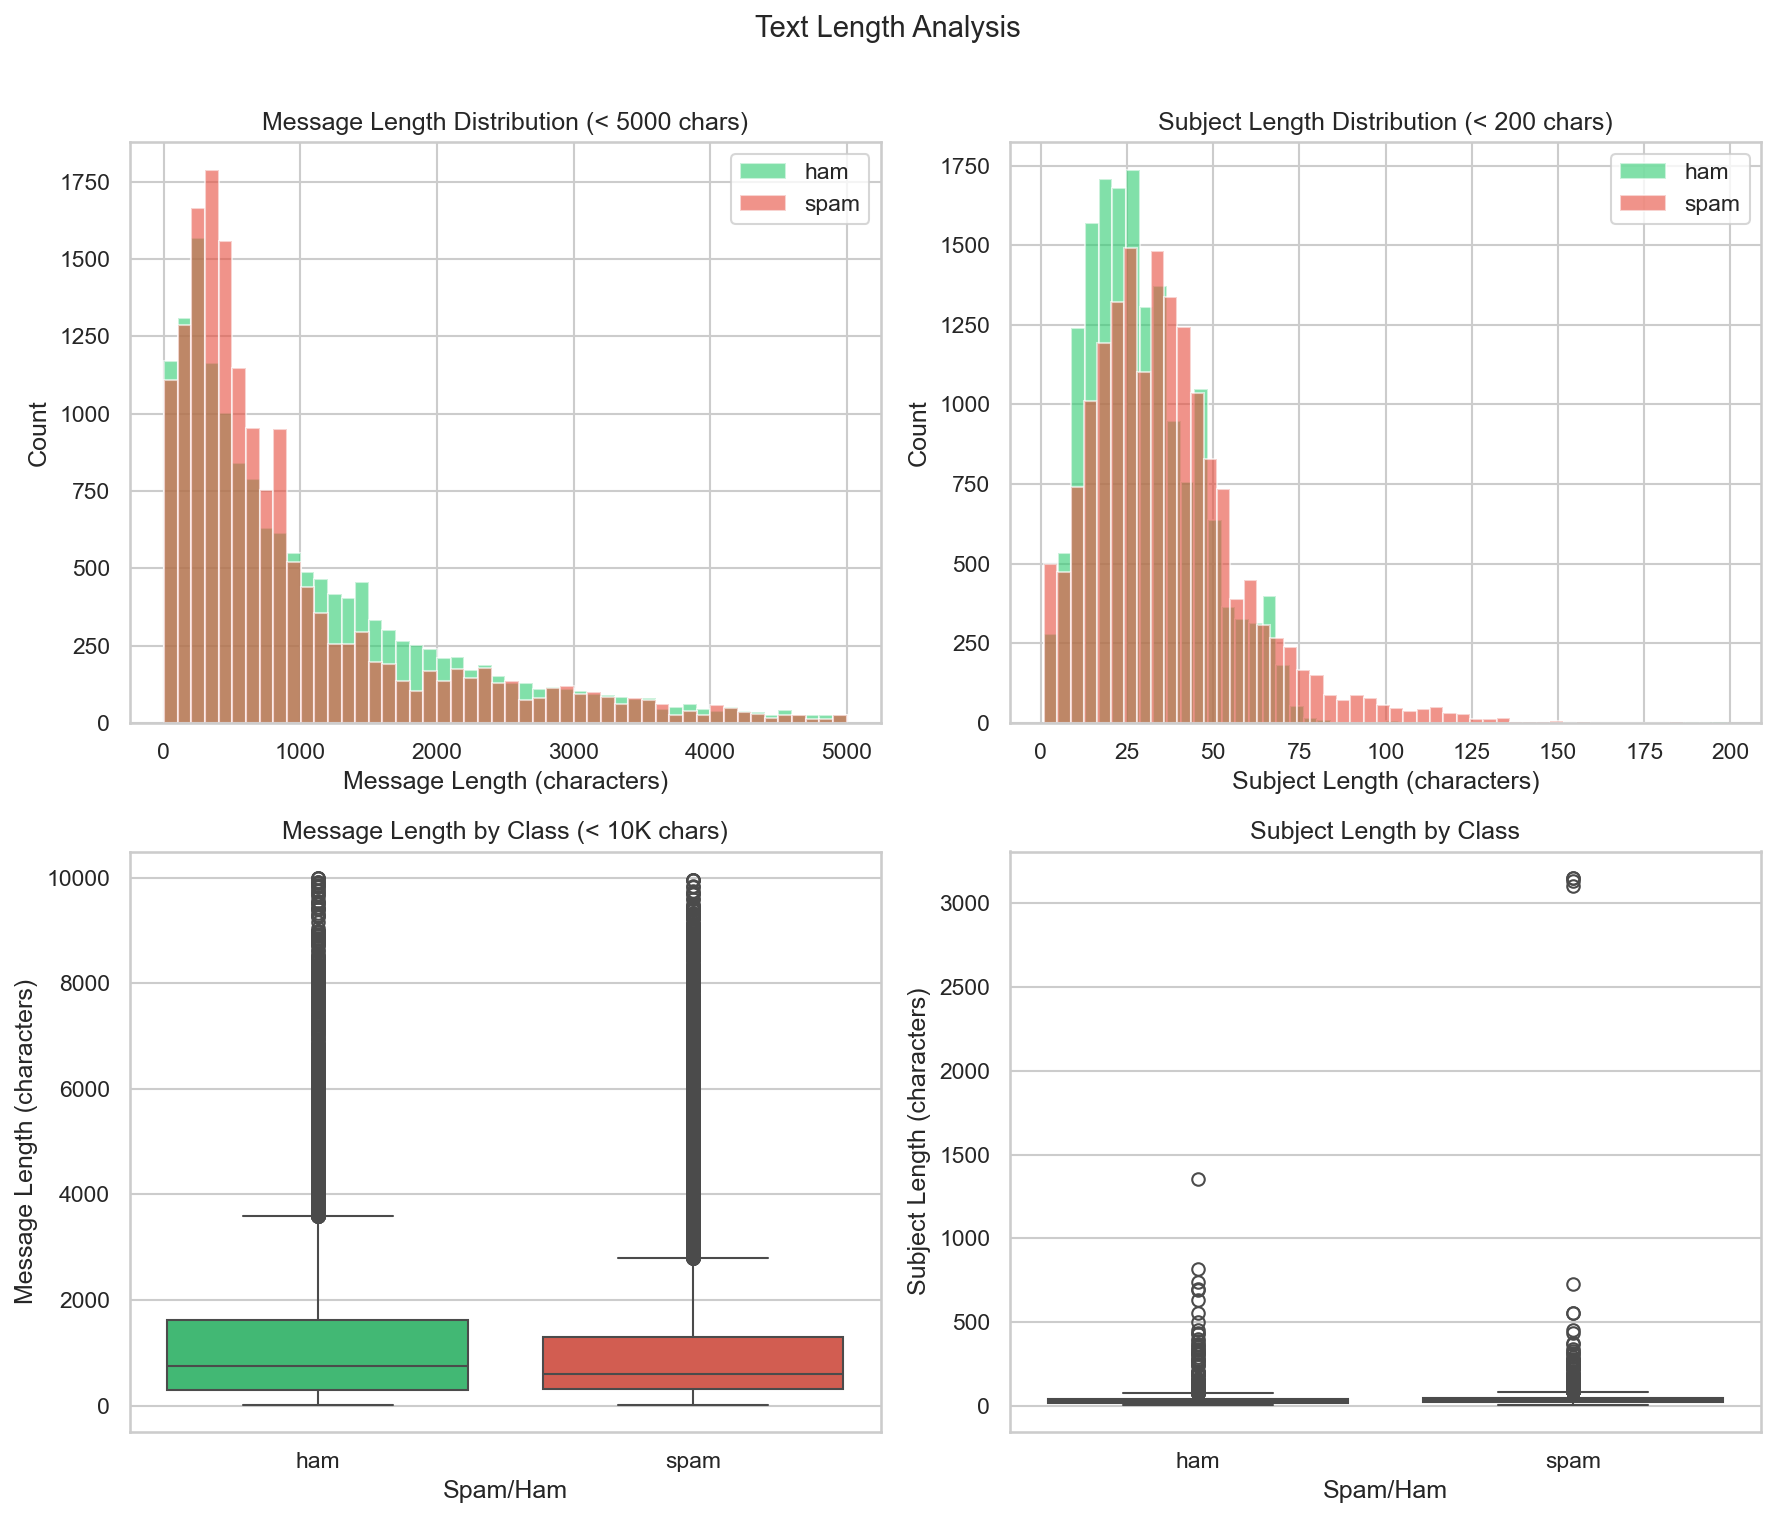

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Message length histograms (capped at 5000 chars for visibility)
for label, color in [('ham', '#2ecc71'), ('spam', '#e74c3c')]:
    subset = df[df['Spam/Ham'] == label]['msg_length']
    axes[0, 0].hist(subset[subset < 5000], bins=50, alpha=0.6, label=label, color=color)
axes[0, 0].set_xlabel('Message Length (characters)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Message Length Distribution (< 5000 chars)')
axes[0, 0].legend()

# Subject length histograms
for label, color in [('ham', '#2ecc71'), ('spam', '#e74c3c')]:
    subset = df[df['Spam/Ham'] == label]['subj_length']
    axes[0, 1].hist(subset[subset < 200], bins=50, alpha=0.6, label=label, color=color)
axes[0, 1].set_xlabel('Subject Length (characters)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Subject Length Distribution (< 200 chars)')
axes[0, 1].legend()

# Message length box plots by class
df_box = df[df['msg_length'] < 10000]
sns.boxplot(data=df_box, x='Spam/Ham', y='msg_length', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, ax=axes[1, 0])
axes[1, 0].set_ylabel('Message Length (characters)')
axes[1, 0].set_title('Message Length by Class (< 10K chars)')

# Subject length box plots by class
sns.boxplot(data=df, x='Spam/Ham', y='subj_length', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, ax=axes[1, 1])
axes[1, 1].set_ylabel('Subject Length (characters)')
axes[1, 1].set_title('Subject Length by Class')

plt.suptitle('Text Length Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Word frequency analysis

Raw word counts in spam vs ham, before any TF-IDF weighting. This is a sanity check more than an analysis I want to see classic spam vocabulary in the spam list and Enron corporatetoo small to work with.

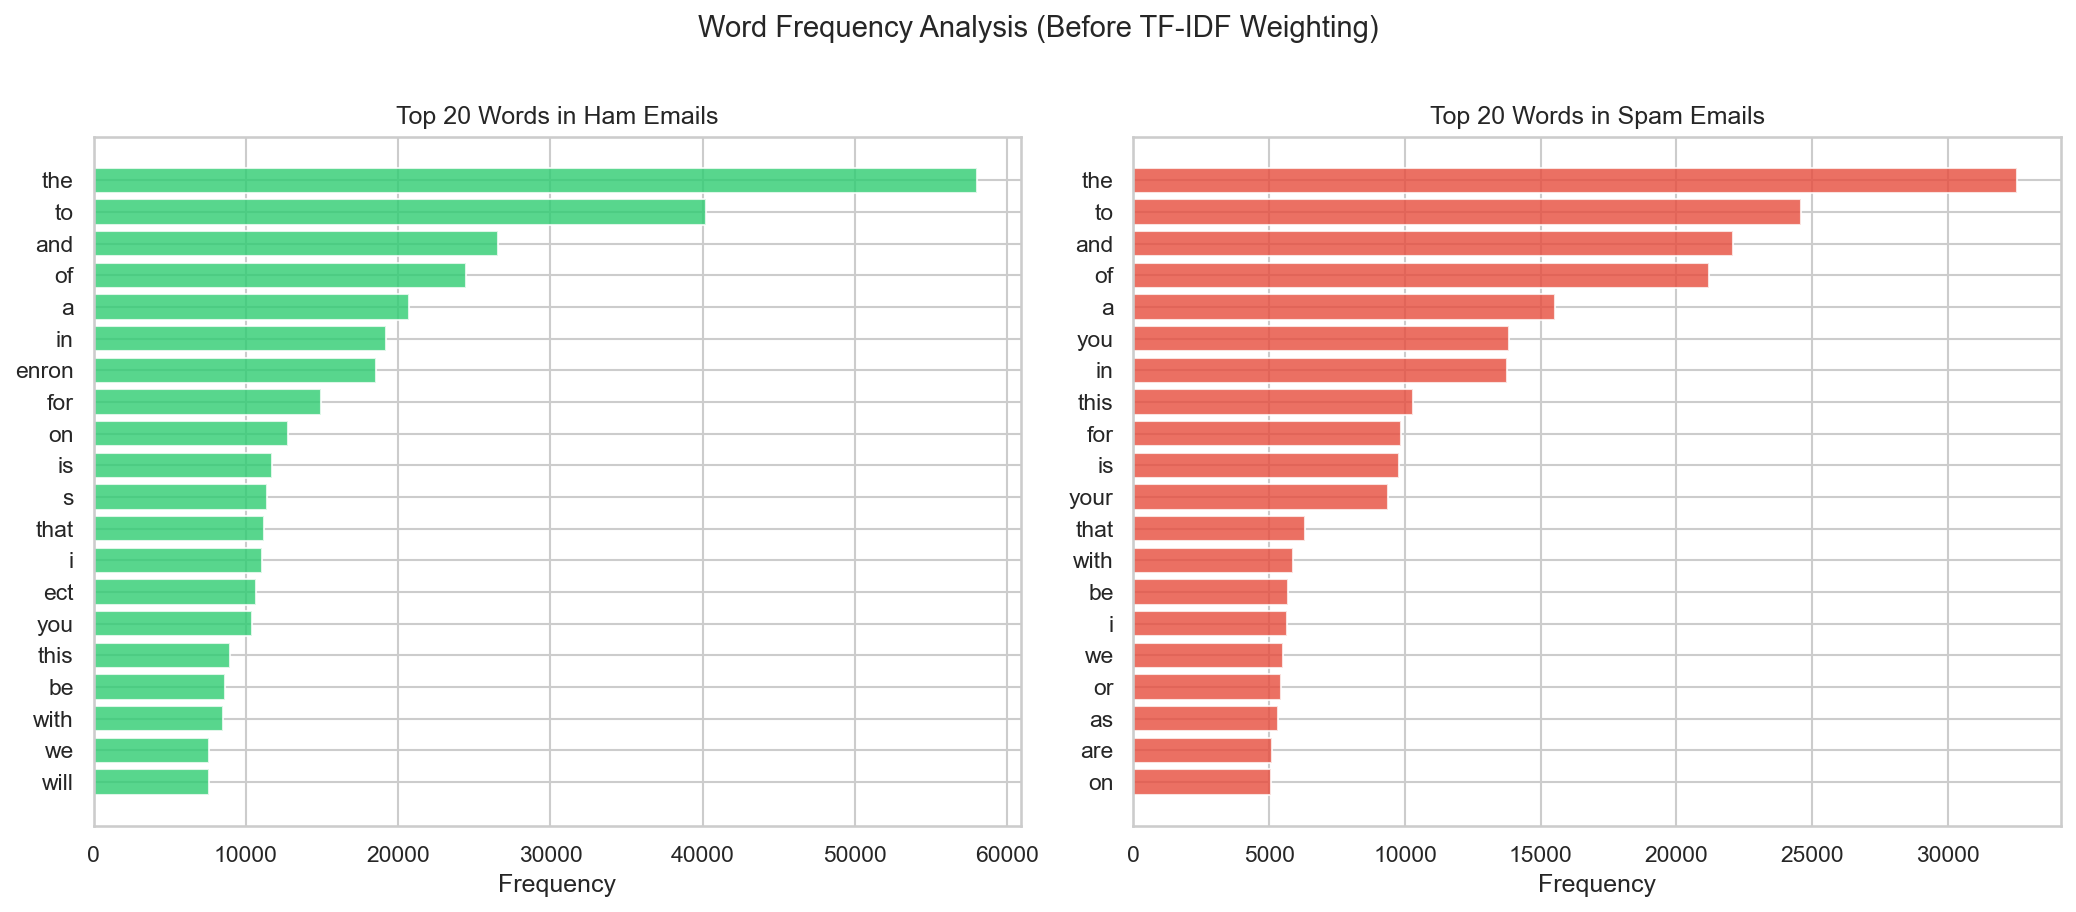

In [7]:
# Clean text and get word frequencies per class
def get_word_counts(texts, top_n=20):
    """Run clean_text on every text and count token frequencies."""
    all_words = []
    for text in texts:
        cleaned = clean_text(text)
        if cleaned:
            all_words.extend(cleaned.split())
    return Counter(all_words).most_common(top_n)

# 5000 emails per class is plenty for a top-20 frequency list and runs
# in a couple of seconds. random_state=42 so the chart is reproducible.
ham_texts = df[df['Spam/Ham'] == 'ham']['Message'].dropna().sample(n=min(5000, len(df[df['Spam/Ham'] == 'ham'])), random_state=42)
spam_texts = df[df['Spam/Ham'] == 'spam']['Message'].dropna().sample(n=min(5000, len(df[df['Spam/Ham'] == 'spam'])), random_state=42)

ham_words = get_word_counts(ham_texts, top_n=20)
spam_words = get_word_counts(spam_texts, top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ham words
words, counts = zip(*ham_words)
axes[0].barh(range(len(words)), counts, color='#2ecc71', alpha=0.8)
axes[0].set_yticks(range(len(words)))
axes[0].set_yticklabels(words)
axes[0].invert_yaxis()
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 20 Words in Ham Emails')

# Spam words
words, counts = zip(*spam_words)
axes[1].barh(range(len(words)), counts, color='#e74c3c', alpha=0.8)
axes[1].set_yticks(range(len(words)))
axes[1].set_yticklabels(words)
axes[1].invert_yaxis()
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 20 Words in Spam Emails')

plt.suptitle('Word Frequency Analysis (Before TF-IDF Weighting)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Word cloud comparison

A more visual version of the previous step. Stopwords get stripped here using scikit-learn's `ENGLISH_STOP_WORDS`, the exact list the TF-IDF vectoriser will use later, so the clouds and the model see the same content vocabulary.

`collocations=False` is set deliberately. Without it, wordcloud would merge frequent two-word phrases ("free money") into single visual entries, which would inflate their apparent dominance and disagree with the unigram frequency chart above.

In [ ]:
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from preprocessing import preprocess_dataset

# Run the full preprocessing pipeline so the cloud sees the same cleaned
# text as the model will at training time.
df_processed = preprocess_dataset(df)

ham_corpus = ' '.join(df_processed[df_processed['label'] == 0]['text'].values)
spam_corpus = ' '.join(df_processed[df_processed['label'] == 1]['text'].values)

# Stopword set = wordcloud defaults + sklearn english + a manual list of
# Enron-specific noise tokens (single letters, abbreviations, dataset
# artefacts like 'ect' and 'hou' which appear in routing headers and
# would otherwise dominate the ham cloud without telling us anything).
stopwords = set(STOPWORDS) | set(ENGLISH_STOP_WORDS) | {
    's', 't', 'ect', 'hou', 'cc', 'e', 'com', 'http', 'www',
    'u', 're', 'don', 'will', 'said', 'know', 'ga', 'na', 'pm',
    'am', 'subject'
}

wc_ham = WordCloud(
    width=800, height=500, background_color='white',
    colormap='Greens', max_words=80, random_state=42,
    collocations=False, stopwords=stopwords
).generate(ham_corpus)

wc_spam = WordCloud(
    width=800, height=500, background_color='white',
    colormap='Reds', max_words=80, random_state=42,
    collocations=False, stopwords=stopwords
).generate(spam_corpus)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(wc_ham, interpolation='bilinear')
axes[0].set_title('Ham Emails', fontsize=16, fontweight='bold', color='#27ae60')
axes[0].axis('off')

axes[1].imshow(wc_spam, interpolation='bilinear')
axes[1].set_title('Spam Emails', fontsize=16, fontweight='bold', color='#c0392b')
axes[1].axis('off')

plt.suptitle('Word Cloud Comparison: Ham vs Spam (Stopwords Removed)', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('../../evaluation/wordcloud_ham_vs_spam.png', dpi=300, bbox_inches='tight')
plt.show()

print('Ham vocabulary is dominated by corporate/Enron-specific terms: enron, energy, gas, trading, houston')
print('Spam vocabulary shows classic spam indicators: money, free, click, price, investment, account, email')

## 7. Impact of preprocessing on text length

How much of the email survives the cleaning pipeline? This section compares the character-length distribution of emails before (raw `Message` body) and after the full preprocessing pipeline (subject + message combined, cleaned). The point is to put a number on the "noise reduction" claim: roughly how much material the headers/URLs/HTML/non-alpha stripping removes, and whether anything important is being lost along with it.

In [ ]:
# Compare text lengths before and after preprocessing
raw_msg_length = df['Message'].astype(str).apply(len)
clean_text_length = df_processed['clean_text_length'] = df_processed['text'].apply(len)

print('Text Length Comparison: Before vs After Preprocessing')
print('=' * 55)
print(f'{"":>25} {"Before":>12} {"After":>12}')
print(f'{"-" * 55}')
print(f'{"Count":>25} {len(raw_msg_length):>12,} {len(clean_text_length):>12,}')
print(f'{"Mean (chars)":>25} {raw_msg_length.mean():>12,.1f} {clean_text_length.mean():>12,.1f}')
print(f'{"Median (chars)":>25} {raw_msg_length.median():>12,.0f} {clean_text_length.median():>12,.0f}')
print(f'{"Std Dev":>25} {raw_msg_length.std():>12,.1f} {clean_text_length.std():>12,.1f}')
print(f'{"Max (chars)":>25} {raw_msg_length.max():>12,} {clean_text_length.max():>12,}')

raw_mean = raw_msg_length.mean()
clean_mean = clean_text_length.mean()
print(f'\nMean length reduction: {raw_mean:,.1f} → {clean_mean:,.1f} ({((raw_mean - clean_mean)/raw_mean)*100:.1f}% reduction)')
print(f'Median length reduction: {raw_msg_length.median():,.0f} → {clean_text_length.median():,.0f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Before preprocessing histogram
raw_capped = raw_msg_length[raw_msg_length < 5000]
axes[0, 0].hist(raw_capped, bins=50, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0, 0].set_xlabel('Character Count')
axes[0, 0].set_ylabel('Number of Emails')
axes[0, 0].set_title('Before Preprocessing\n(Raw Message Body, < 5000 chars)', fontsize=11)
axes[0, 0].axvline(raw_msg_length.median(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Median: {raw_msg_length.median():,.0f}')
axes[0, 0].legend(fontsize=9)

# Top-right: After preprocessing histogram
clean_capped = clean_text_length[clean_text_length < 5000]
axes[0, 1].hist(clean_capped, bins=50, color='#e67e22', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0, 1].set_xlabel('Character Count')
axes[0, 1].set_ylabel('Number of Emails')
axes[0, 1].set_title('After Preprocessing\n(Cleaned Subject + Message, < 5000 chars)', fontsize=11)
axes[0, 1].axvline(clean_text_length.median(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Median: {clean_text_length.median():,.0f}')
axes[0, 1].legend(fontsize=9)

# Bottom-left: Overlaid comparison
axes[1, 0].hist(raw_capped, bins=50, alpha=0.5, color='#3498db', label='Before', edgecolor='black', linewidth=0.2)
axes[1, 0].hist(clean_capped, bins=50, alpha=0.5, color='#e67e22', label='After', edgecolor='black', linewidth=0.2)
axes[1, 0].set_xlabel('Character Count')
axes[1, 0].set_ylabel('Number of Emails')
axes[1, 0].set_title('Before vs After Overlay (< 5000 chars)', fontsize=11)
axes[1, 0].legend(fontsize=10)

# Bottom-right: After preprocessing by class
for label, color, name in [(0, '#2ecc71', 'Ham'), (1, '#e74c3c', 'Spam')]:
    subset = df_processed[df_processed['label'] == label]['clean_text_length']
    axes[1, 1].hist(subset[subset < 5000], bins=50, alpha=0.6, color=color,
                     label=name, edgecolor='black', linewidth=0.2)
axes[1, 1].set_xlabel('Character Count')
axes[1, 1].set_ylabel('Number of Emails')
axes[1, 1].set_title('After Preprocessing by Class (< 5000 chars)', fontsize=11)
axes[1, 1].legend(fontsize=10)

plt.suptitle('Impact of Text Preprocessing on Email Length Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../evaluation/text_length_before_vs_after.png', dpi=300, bbox_inches='tight')
plt.show()

# By-class stats after preprocessing
print('\nAfter preprocessing, by class:')
for label, name in [(0, 'Ham'), (1, 'Spam')]:
    subset = df_processed[df_processed['label'] == label]['clean_text_length']
    print(f'  {name}: mean={subset.mean():,.1f}, median={subset.median():,.0f}, max={subset.max():,}')

## 8. Summary statistics

A compact stats table I can drop straight into the dissertation write-up without re-deriving the numbers.

In [8]:
summary = pd.DataFrame({
    'Metric': [
        'Total Emails',
        'Ham Emails',
        'Spam Emails',
        'Class Balance (spam %)',
        'Empty Message Bodies',
        'Median Message Length (chars)',
        'Mean Message Length (chars)',
        'Max Message Length (chars)',
        'Median Subject Length (chars)',
        'Date Range'
    ],
    'Value': [
        f"{len(df):,}",
        f"{(df['Spam/Ham'] == 'ham').sum():,}",
        f"{(df['Spam/Ham'] == 'spam').sum():,}",
        f"{(df['Spam/Ham'] == 'spam').mean() * 100:.1f}%",
        f"{(df['Message'].isna() | (df['Message'].astype(str).str.strip() == '')).sum():,}",
        f"{df['msg_length'].median():,.0f}",
        f"{df['msg_length'].mean():,.0f}",
        f"{df['msg_length'].max():,}",
        f"{df['subj_length'].median():,.0f}",
        f"{df['Date'].dropna().min()} to {df['Date'].dropna().max()}"
    ]
})

print('Dataset Summary')
print('=' * 50)
print(summary.to_string(index=False))

Dataset Summary
                       Metric                    Value
                 Total Emails                   33,716
                   Ham Emails                   16,545
                  Spam Emails                   17,171
       Class Balance (spam %)                    50.9%
         Empty Message Bodies                      371
Median Message Length (chars)                      675
  Mean Message Length (chars)                    1,470
   Max Message Length (chars)                  228,353
Median Subject Length (chars)                       30
                   Date Range 1999-12-10 to 2005-09-06


## Key observations

1. Class balance is essentially 50/50 (50.9% spam, 49.1% ham), so accuracy is a valid headline metric and no resampling is needed.
2. Plenty of rows have empty message bodies but a valid subject line. Combining Subject + Message during preprocessing keeps those rows alive instead of dropping them.
3. Message lengths span a huge range, from 1 character to 228K+. TF-IDF handles this naturally via its term-frequency normalisation, and DistilBERT will truncate at 256 tokens so the long tail does not dominate.
4. Spam subject lines are noticeably longer on average than ham subjects, which lines up with what the word frequency chart shows: spam stuffs the subject with bait words.
5. The most common words overlap heavily between classes ("the", "to", "and", and so on). That is exactly what TF-IDF's IDF term is designed to downweight, and it is the reason the vectoriser uses sklearn's English stopword list.